In [57]:
### Code to read in h5 files as detailed in the first guidebook
# Import necessary packages
import sys

sys.path.append(r"C:\Users\lwlav\.vscode\repo\BOEM-Oak-Island\Post_Processing_Scripts")
import pandas as pd
import os
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy import signal
import glob
import utide
plt.rcParams.update({'font.size': 14}) 

deployment_num = [1,2,3,4,5]
sensor_spot = ["S", "C", "E"]
# directory_initial_user_path = r"/Volumes/BOEM/"  # Katherine
# directory_initial_user_path = r"/Volumes/kanarde/BOEM/"  # Brooke
directory_initial_user_path = r"Z:/"  # Levi

def tidal_ellipse(u,v,t,constituents = ['M2'], sensor = "S0",dep = "1",plotter = True):
 
    coef = utide.solve(t, u, v, lat=33.9, method="ols", conf_int="linear", constit=constituents)

    #With coefficients, we can reconstruct the tidal signal and plot the ellipses
    out = utide.reconstruct(t, coef)

    # Extract the fitted velocities
    u_fit = out.u
    v_fit = out.v
    if plotter == True:
        # Plotting the ellipse
        plt.figure(figsize=(6, 6))
        plt.plot(v_fit,u_fit, label='Reconstructed Tidal Ellipse')
        plt.axhline(0, color='black', lw=1, ls='--')
        plt.axvline(0, color='black', lw=1, ls='--')
        plt.xlabel("East Velocity (m/s)")
        plt.ylabel("North Velocity (m/s)")
        plt.title(f"Tidal Ellipse for {constituents[0]} - sensor {sensor} - Deployment {dep}")
        plt.axis('equal') # Crucial for seeing the true shape of the ellipse
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    #Remove tidal ellipse from original signal to get residuals
    u_residual = u - u_fit
    v_residual = v - v_fit

    return coef, out, pd.DataFrame({
        "U_residual": u_residual,
        "V_residual": v_residual
    })


In [58]:
# Import bulkstats and create dictionary for each sensor
for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
            print(f"Processing {sensor_location}...")
            files = ["DepthAveragedFlowDirection", "DepthAveragedCurrentVelocity","Time","DepthAveragedEastVelocity","DepthAveragedNorthVelocity"]
            waves = {}
            for file in files:
                file_path = os.path.join(sensor_id, file)  # file path
                df = pd.read_hdf(file_path)  # read the file into a Pandas dataframe
                file_name = file.split(".")[0]  # file name
                print(file_name)
                waves[file_name] = df  # store dataframe
            globals()[f"waves_{sensor_location}_{dep}"] = waves

Processing S0...
DepthAveragedFlowDirection
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Processing S1...
DepthAveragedFlowDirection
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Processing E1...
DepthAveragedFlowDirection
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Processing S0...
DepthAveragedFlowDirection
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Processing S1...
DepthAveragedFlowDirection
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Processing E1...
DepthAveragedFlowDirection
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Processing S0...
DepthAveragedFlowDirection
DepthAveragedCurrentVelocity
Time
DepthAveragedEastVelocity
DepthAveragedNorthVelocity
Processing C0...
DepthAveragedFlowDirection
DepthAveragedCurrentVelocity
Time
Depth

In [76]:
#Transform vels into alongshoal and cross-shoal components
for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1

            print(f"Processing {sensor_location}...")
            waves = globals()[f"waves_{sensor_location}_{dep}"]
            shoal_bearing = 169 
            # math radians not nautical
            theta = np.radians(90 -shoal_bearing) 

            u = waves["DepthAveragedEastVelocity"].values.squeeze()
            v = waves["DepthAveragedNorthVelocity"].values.squeeze()

            along_shore_vel = u * np.cos(theta) + v * np.sin(theta)
            cross_shore_vel = -u * np.sin(theta) + v * np.cos(theta)

            waves["AlongShoreVelocity"] = along_shore_vel
            waves["CrossShoreVelocity"] = cross_shore_vel
            globals()[f"waves_{sensor_location}_{dep}"] = waves

Processing S0...
Processing S1...
Processing E1...
Processing S0...
Processing S1...
Processing E1...
Processing S0...
Processing C0...
Processing E0...
Processing S1...
Processing E1...
Processing S1...
Processing C0...


Processing S0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing E1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing E1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing C0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing E0...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing E1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing S1...
solve: matrix prep ... solution ... done.
prep/calcs ... done.
Processing C0...
solve: matrix prep ... 

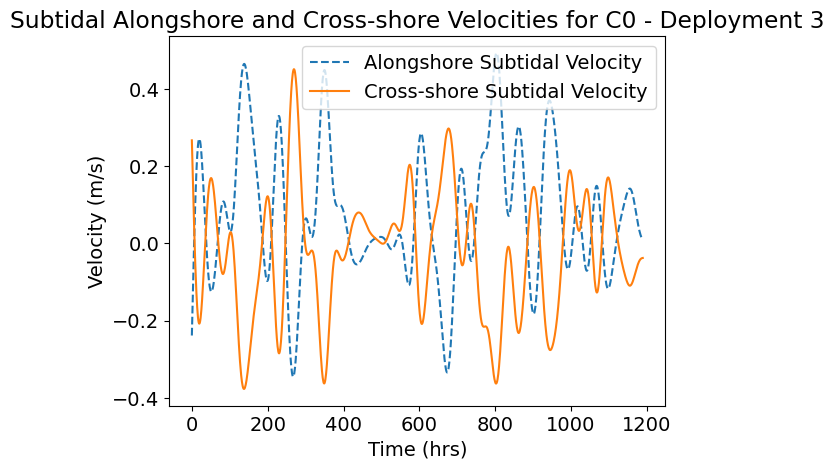

In [108]:
###Low pass filter at 48hours to get subtidal flows
from spectral_sediment import lowpass_filter
for dep in deployment_num:
    for spots in sensor_spot:
        initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
        sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
        for sensor_id in sensor_ids:# Extract S0 or S1
            sensor_location = os.path.basename(sensor_id)
            sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
            print(f"Processing {sensor_location}...")
            waves = globals()[f"waves_{sensor_location}_{dep}"]
            for vel in ["AlongShoreVelocity", "CrossShoreVelocity"]:
                filtered_vel = lowpass_filter(waves[vel], cutoff=1/48, fs=1)  # fs=1 for hourly data
                waves[f"{vel}_Subtidal"] = filtered_vel
            coef, out, residuals = tidal_ellipse(waves["DepthAveragedEastVelocity"].values.squeeze(), 
                                              waves["DepthAveragedNorthVelocity"].values.squeeze(), 
                                              waves["Time"].values.squeeze(), 
                                              constituents=['M2'], 
                                              sensor=sensor_location, 
                                              dep=dep,
                                              plotter=False)
            waves["EastVelocity_Residual"] = residuals["U_residual"]
            waves["NorthVelocity_Residual"] = residuals["V_residual"]
            globals()[f"waves_{sensor_location}_{dep}"] = waves

plt.plot(waves_C0_3["AlongShoreVelocity_Subtidal"], label="Alongshore Subtidal Velocity", linestyle='--')
plt.plot(waves_C0_3["CrossShoreVelocity_Subtidal"], label="Cross-shore Subtidal Velocity")
plt.xlabel("Time (hrs)")
plt.ylabel("Velocity (m/s)")
plt.title("Subtidal Alongshore and Cross-shore Velocities for C0 - Deployment 3")
plt.legend()
plt.show()

['Z:/deployment_3/BulkStats\\S0_101418']
Processing S0...
S0
['Z:/deployment_3/BulkStats\\C0_103071']
Processing C0...
C0
['Z:/deployment_3/BulkStats\\E0_103080']
Processing E0...
E0


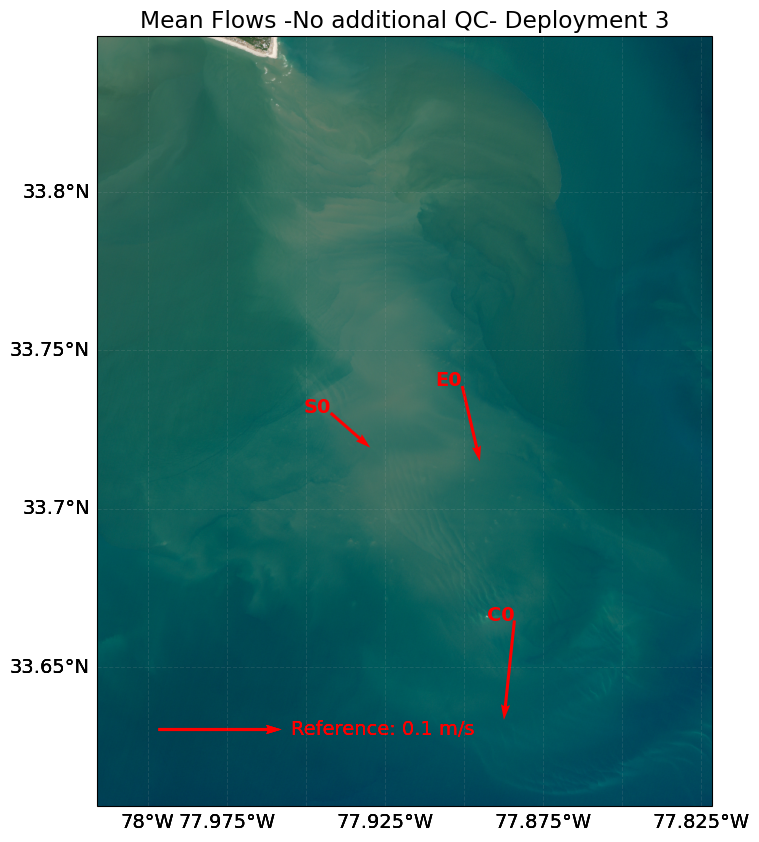

In [116]:
# Convert dep to string to match filename parsing
import rasterio
import cartopy.crs as ccrs

filepath = r"z:\deployment_2\2024-11-25_16bitTiff.tiff"
filepath  = r"z:\deployment_3\2025-02-28-16bitTiff.tiff"

# 1. Setup the Map
src = rasterio.open(filepath)
img16 = src.read()
# Basic normalization for 8-bit display
img8 = ((img16 - np.min(img16)) / (np.max(img16) - np.min(img16)) * 255).astype(np.uint8)

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": ccrs.PlateCarree()})

extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
ax.imshow(
    img8.transpose(1, 2, 0),
    origin="upper",
    extent=extent, 
    transform=ccrs.PlateCarree()
)

# 2. Define Lander Coordinates (Update these with real locations!)
# Format: "LanderName": (Longitude, Latitude)
lander_coords = {
"S0": (-77.942100, 33.730200),
"S1": (-77.983700, 33.793700),
"C0": (-77.884083, 33.664683),
"E0": (-77.900567, 33.738750),
"E1": (-77.924600, 33.805600) # 33.805593 -77.924593$
}

dep = 3
for spots in sensor_spot:
    initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
    sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
    print(sensor_ids)
    for sensor_id in sensor_ids:
        sensor_location = os.path.basename(sensor_id)
        sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
        data = globals()[f"waves_{sensor_location}_{dep}"]
        print(f"Processing {sensor_location}...")

        # Extract velocities
        u = np.nanmean(data['DepthAveragedEastVelocity'])
        v = np.nanmean(data['DepthAveragedNorthVelocity'])
        # Get coords from dictionary, default to S0 if not found

        sensor = str(sensor_location)
        print(sensor)
        lon, lat = lander_coords.get(sensor, lander_coords["S0"])

        # 4. Plot Vector
        q = ax.quiver(
            lon, lat, u, v,
            transform=ccrs.PlateCarree(),
            color='red', 
            scale=0.5,      # Adjust based on current speeds
            width=0.005
        )
        qk = ax.quiverkey(q, 
            X=0.3, Y=0.1, # Position on the plot
            U=0.1,        # The length of the reference arrow (e.g., 0.01 m/s)
            label='Reference: 0.1 m/s', 
            labelpos='E',
            color='red',
            labelcolor='red'
            )
    
    
        # Add a label for the lander
        ax.text(lon, lat, sensor_location, transform=ccrs.PlateCarree(), 
                fontsize=14, fontweight='bold', ha='right',color='red')


        # Gridlines and Labels
        gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.05)
        gl.top_labels = False
        gl.right_labels = False
    plt.title(f"Mean Flows -No additional QC- Deployment {dep}")

['Z:/deployment_3/BulkStats\\S0_101418']
Processing S0...
S0
1.5762425658258394e-17 1.5762425658258394e-17
['Z:/deployment_3/BulkStats\\C0_103071']
Processing C0...
C0
1.791284207798572e-17 1.791284207798572e-17
['Z:/deployment_3/BulkStats\\E0_103080']
Processing E0...
E0
1.4617936490897893e-17 8.881784197001253e-18


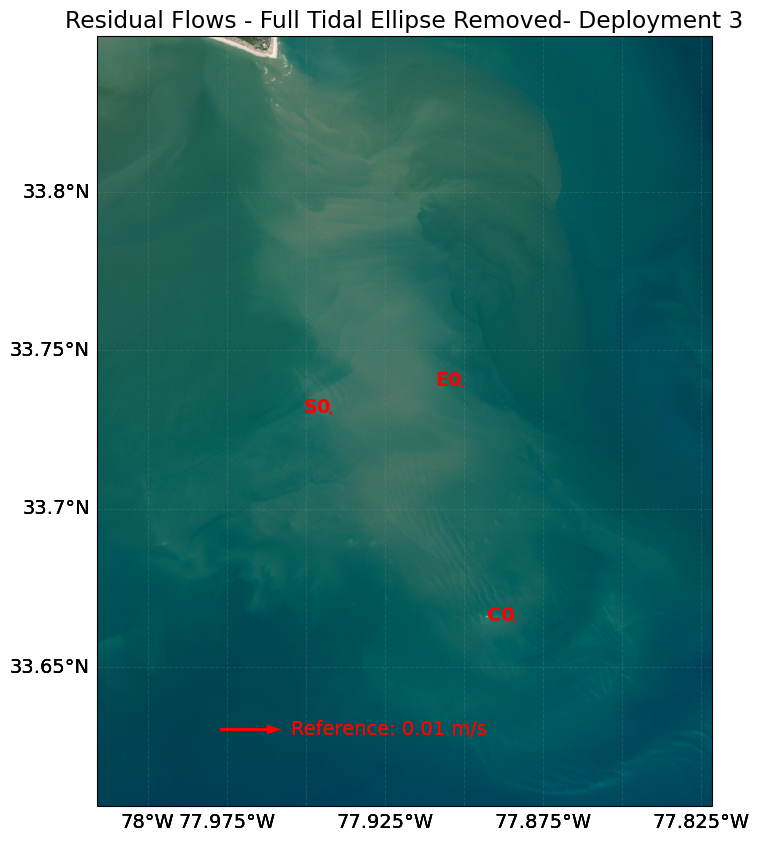

In [115]:
# Convert dep to string to match filename parsing
import rasterio
import cartopy.crs as ccrs

filepath = r"z:\deployment_2\2024-11-25_16bitTiff.tiff"
filepath  = r"z:\deployment_3\2025-02-28-16bitTiff.tiff"
# 1. Setup the Map
src = rasterio.open(filepath)
img16 = src.read()
# Basic normalization for 8-bit display
img8 = ((img16 - np.min(img16)) / (np.max(img16) - np.min(img16)) * 255).astype(np.uint8)

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": ccrs.PlateCarree()})

extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
ax.imshow(
    img8.transpose(1, 2, 0),
    origin="upper",
    extent=extent, 
    transform=ccrs.PlateCarree()
)

# 2. Define Lander Coordinates (Update these with real locations!)
# Format: "LanderName": (Longitude, Latitude)
lander_coords = {
"S0": (-77.942100, 33.730200),
"S1": (-77.983700, 33.793700),
"C0": (-77.884083, 33.664683),
"E0": (-77.900567, 33.738750),
"E1": (-77.924600, 33.805600) # 33.805593 -77.924593$
}

dep = 3
for spots in sensor_spot:
    initpath = os.path.join(directory_initial_user_path, f"/deployment_{dep}/BulkStats")
    sensor_ids = glob.glob(os.path.join(initpath, f"{spots}[0-9]*"))
    print(sensor_ids)
    for sensor_id in sensor_ids:
        sensor_location = os.path.basename(sensor_id)
        sensor_location = sensor_location.split("_")[0]  # Extract S0 or S1
        data = globals()[f"waves_{sensor_location}_{dep}"]
        print(f"Processing {sensor_location}...")

        # Extract velocities
        u = np.nanmean(data['EastVelocity_Residual'])
        v = np.nanmean(data['NorthVelocity_Residual'])
        # Get coords from dictionary, default to S0 if not found

        sensor = str(sensor_location)
        print(sensor)
        lon, lat = lander_coords.get(sensor, lander_coords["S0"])
        print(u,v)
        # 4. Plot Vector
        q = ax.quiver(
            lon, lat, u, v,
            transform=ccrs.PlateCarree(),
            color='red', 
            scale=.1,      # Adjust based on current speeds
            width=0.005
        )
        # After your q = ax.quiver(...) call
        qk = ax.quiverkey(q, 
                X=0.3, Y=0.1, # Position on the plot
                U=0.01,        # The length of the reference arrow (e.g., 0.01 m/s)
                label='Reference: 0.01 m/s', 
                labelpos='E',
                color='red',
                labelcolor='red'
                )

        # Add a label for the lander
        ax.text(lon, lat, sensor_location, transform=ccrs.PlateCarree(), 
                fontsize=14, fontweight='bold', ha='right',color='red')


        # Gridlines and Labels
        gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.05)
        gl.top_labels = False
        gl.right_labels = False
    plt.title(f"Residual Flows - Full Tidal Ellipse Removed- Deployment {dep}")

solve: matrix prep ... solution ... done.
prep/calcs ... done.


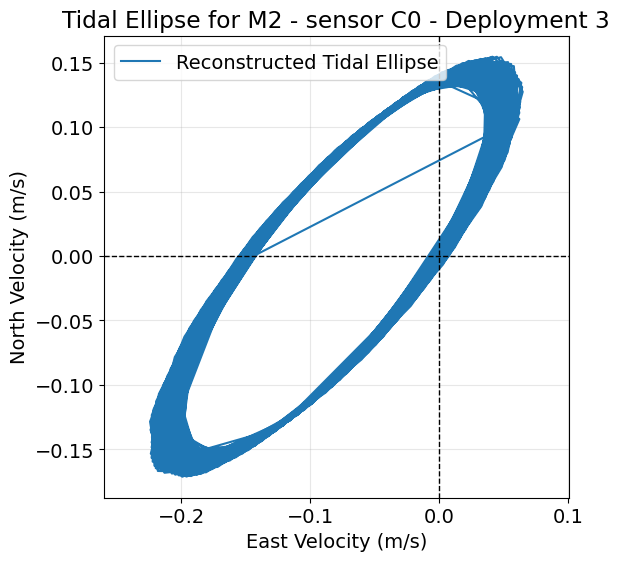

In [114]:
u = waves_C0_3["DepthAveragedEastVelocity"].values.squeeze()
v = waves_C0_3["DepthAveragedNorthVelocity"].values.squeeze()
coef, out, resid = tidal_ellipse(u, v, waves_C0_3["Time"].values.squeeze(), constituents=['M2'], sensor="C0", dep=dep,plotter=True)